In [1]:
# Project 2 - Customer Segmentation
# Step 1 - Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        

/kaggle/input/datasets/ayesha09q/marketing-analytics/ifood_df.csv


In [7]:
# Step 3 - Load Dataset
df = pd.read_csv('/kaggle/input/datasets/ayesha09q/marketing-analytics/ifood_df.csv')
print("Data loaded successfully!")
print("Shape:", df.shape)
print(df.head())

Data loaded successfully!
Shape: (2205, 39)
    Income  Kidhome  Teenhome  Recency  MntWines  MntFruits  MntMeatProducts  \
0  58138.0        0         0       58       635         88              546   
1  46344.0        1         1       38        11          1                6   
2  71613.0        0         0       26       426         49              127   
3  26646.0        1         0       26        11          4               20   
4  58293.0        1         0       94       173         43              118   

   MntFishProducts  MntSweetProducts  MntGoldProds  ...  marital_Together  \
0              172                88            88  ...                 0   
1                2                 1             6  ...                 0   
2              111                21            42  ...                 1   
3               10                 3             5  ...                 1   
4               46                27            15  ...                 0   

   marital_W

In [8]:
# Step 4 - Data Exploration
print("=== Column Names ===")
print(df.columns.tolist())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
print(df[['Income', 'Age', 'MntWines', 'MntMeatProducts']].describe().round(2))

=== Column Names ===
['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'Age', 'Customer_Days', 'marital_Divorced', 'marital_Married', 'marital_Single', 'marital_Together', 'marital_Widow', 'education_2n Cycle', 'education_Basic', 'education_Graduation', 'education_Master', 'education_PhD', 'MntTotal', 'MntRegularProds', 'AcceptedCmpOverall']

=== Missing Values ===
Income                  0
Kidhome                 0
Teenhome                0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchas

In [12]:
# Step 5 - Clean Data
# Drop missing values
df = df.dropna()

# Total spending already exists as MntTotal!
print("Data cleaned successfully!")
print("Shape after cleaning:", df.shape)
print(df[['Age', 'Income', 'MntTotal']].head())

Data cleaned successfully!
Shape after cleaning: (2205, 39)
   Age   Income  MntTotal
0   63  58138.0      1529
1   66  46344.0        21
2   55  71613.0       734
3   36  26646.0        48
4   39  58293.0       407


In [11]:
print(df.columns.tolist())

['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'Age', 'Customer_Days', 'marital_Divorced', 'marital_Married', 'marital_Single', 'marital_Together', 'marital_Widow', 'education_2n Cycle', 'education_Basic', 'education_Graduation', 'education_Master', 'education_PhD', 'MntTotal', 'MntRegularProds', 'AcceptedCmpOverall']


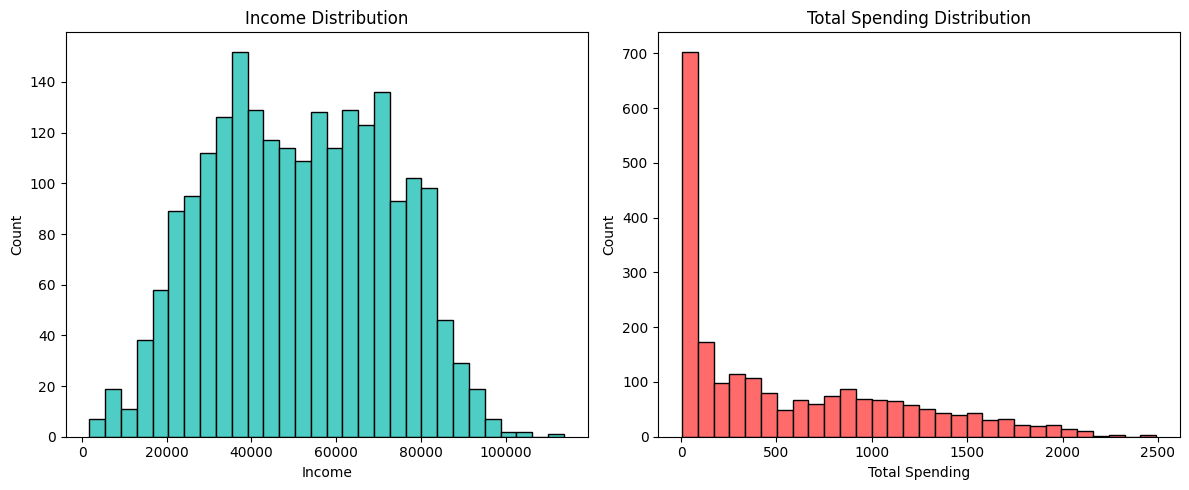

In [13]:
# Step 6 - Visualize Data
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Income Distribution
axes[0].hist(df['Income'], bins=30, color='#4ECDC4', edgecolor='black')
axes[0].set_title('Income Distribution')
axes[0].set_xlabel('Income')
axes[0].set_ylabel('Count')

# Spending Distribution
axes[1].hist(df['MntTotal'], bins=30, color='#FF6B6B', edgecolor='black')
axes[1].set_title('Total Spending Distribution')
axes[1].set_xlabel('Total Spending')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [14]:
# Step 7 - K-Means Clustering
# Select features for clustering
X = df[['Income', 'MntTotal', 'Age', 'Recency']]

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply KMeans with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("Clustering done!")
print(df['Cluster'].value_counts())

Clustering done!
Cluster
0    593
3    573
1    568
2    471
Name: count, dtype: int64


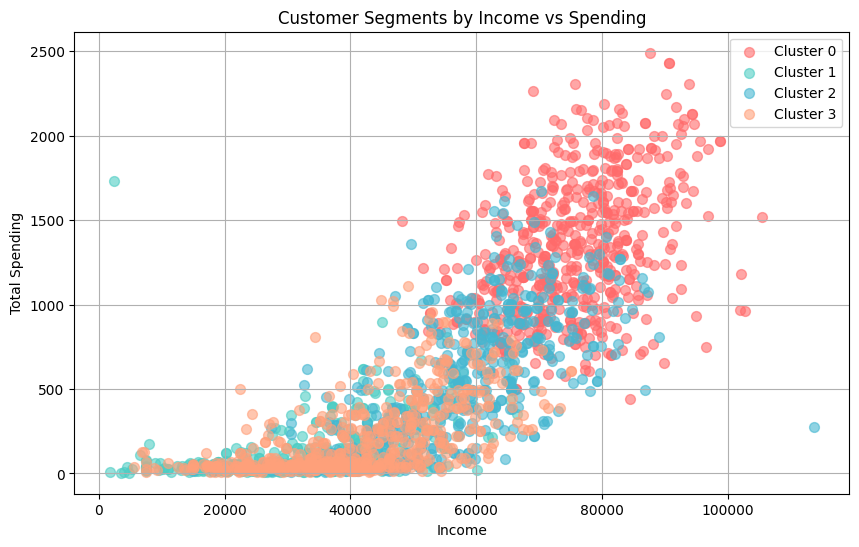

In [15]:
# Step 8 - Visualize Clusters
plt.figure(figsize=(10, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

for cluster in range(4):
    mask = df['Cluster'] == cluster
    plt.scatter(df[mask]['Income'], df[mask]['MntTotal'],
                c=colors[cluster], label=f'Cluster {cluster}',
                alpha=0.6, s=50)

plt.title('Customer Segments by Income vs Spending')
plt.xlabel('Income')
plt.ylabel('Total Spending')
plt.legend()
plt.grid(True)
plt.show()

=== Average Values per Cluster ===
           Income  MntTotal    Age  Recency
Cluster                                    
0        75151.61   1320.17  49.47    55.61
1        32431.86    116.63  42.77    30.65
2        57986.68    579.10  62.35    27.25
3        41062.47    207.74  51.78    78.27


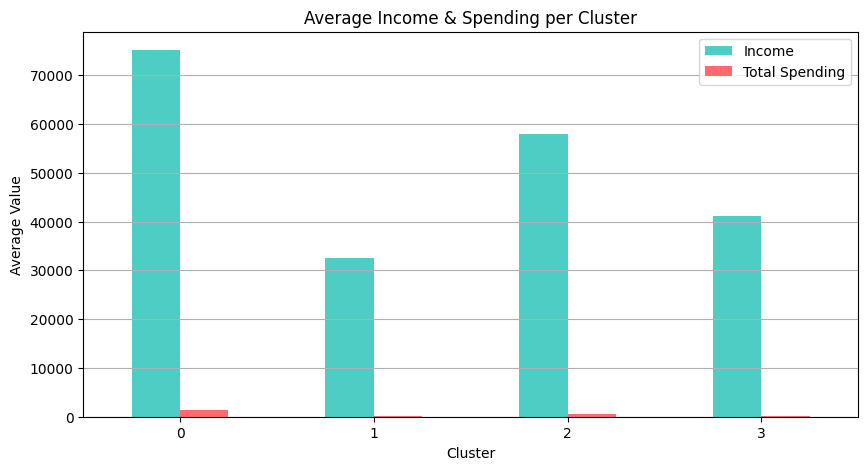

In [16]:
# Step 9 - Analyze Each Cluster
cluster_analysis = df.groupby('Cluster')[['Income', 'MntTotal', 
                                          'Age', 'Recency']].mean().round(2)
print("=== Average Values per Cluster ===")
print(cluster_analysis)

# Bar chart
cluster_analysis[['Income', 'MntTotal']].plot(kind='bar', 
                                               figsize=(10,5),
                                               color=['#4ECDC4','#FF6B6B'])
plt.title('Average Income & Spending per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.legend(['Income', 'Total Spending'])
plt.grid(axis='y')
plt.show()

In [17]:
# Step 10 - Final Summary & Recommendations
print("=" * 55)
print("   CUSTOMER SEGMENTATION ANALYSIS - SUMMARY")
print("=" * 55)

print(f"\n Total Customers: {len(df)}")
print(f" Total Clusters: 4")

print("\n=== CLUSTER DESCRIPTIONS ===")
for cluster in range(4):
    mask = df['Cluster'] == cluster
    avg_income = df[mask]['Income'].mean()
    avg_spending = df[mask]['MntTotal'].mean()
    count = mask.sum()
    print(f"\n Cluster {cluster}:")
    print(f"   Customers: {count}")
    print(f"   Avg Income: {avg_income:.0f}")
    print(f"   Avg Spending: {avg_spending:.0f}")

print("\n=== RECOMMENDATIONS ===")
print(" 1. Target high income clusters with premium products")
print(" 2. Offer discounts to low spending clusters")
print(" 3. Re-engage clusters with high recency")
print(" 4. Focus retention on high spending clusters")
print("=" * 55)
print(" Customer Segmentation Completed!")
print("=" * 55)

   CUSTOMER SEGMENTATION ANALYSIS - SUMMARY

 Total Customers: 2205
 Total Clusters: 4

=== CLUSTER DESCRIPTIONS ===

 Cluster 0:
   Customers: 593
   Avg Income: 75152
   Avg Spending: 1320

 Cluster 1:
   Customers: 568
   Avg Income: 32432
   Avg Spending: 117

 Cluster 2:
   Customers: 471
   Avg Income: 57987
   Avg Spending: 579

 Cluster 3:
   Customers: 573
   Avg Income: 41062
   Avg Spending: 208

=== RECOMMENDATIONS ===
 1. Target high income clusters with premium products
 2. Offer discounts to low spending clusters
 3. Re-engage clusters with high recency
 4. Focus retention on high spending clusters
 Customer Segmentation Completed!
